### 1. Imports & Dependencies

- `pandas`, `numpy`, `os`, `glob` — จัดการ data และไฟล์
- `pybaselines.Baseline` — drPLS baseline correction
- `scipy.signal.savgol_filter` — Savitzky–Golay smoothing
- `sklearn.metrics` — accuracy / precision / F1 / confusion matrix
- `sklearn.decomposition.PCA` + `sklearn.inspection.permutation_importance` — analysis tools
- `matplotlib`, `seaborn` — visualization

In [7]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from pybaselines import Baseline
from scipy.signal import savgol_filter
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, f1_score , ConfusionMatrixDisplay , precision_score
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.inspection import permutation_importance

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### 2. Pipeline Helper Functions (Preprocessing Suite)

- **`load_raman_recursive`** — recursive `glob('**/*.txt')` → concat ทุกไฟล์เป็น DataFrame เดียว, ใช้ folder name เป็น label
- **`encode_df`** — สร้างคอลัมน์ binary `Target` / `Target_Code` (No THC = 0, THC = 1) ให้ทั้ง 3 dataset (cal, select, solv)
- **`remove_duplicates`** — long → matrix reshape โดยใช้ `np.diff(wave_raw)` ตรวจทิศทาง + หา period จาก reset point แรก
- **`preprocessing`** — chain มาตรฐาน: drPLS baseline (`lam=1e6, eta=0.5`) → SavGol (`window=15, poly=2`) → SNR cutoff (>0.5) → SNV normalize, ใช้ mask เดียวคัด intensity / Y / Conc พร้อมกัน
- **`crop_spectra`** — crop ช่วง 620–1700 cm⁻¹ (Full Spectra view)
- **`select_peaks`** — เลือก index ใกล้ peak ที่กำหนดด้วย `np.argmin(|wave - p|)` (Selected Peaks view)
- **`sersmap`** — เฉลี่ย 25 spectra ต่อหนึ่งจุด → `reshape(-1, 25, n_wav).mean(axis=1)` (SERS-averaged view)

In [8]:
#LOAD DATA
def load_raman_recursive(base_path, label_col_name='Label'): #Label_col ไว้เผื่อที่จะนำมาสร้าง 
    head = ['X','Y','Wave', 'Intensity']
    file_list = glob.glob(os.path.join(base_path, "**/*.txt"), recursive=True) #ค้นหาไฟล์ที่มี .txt รวมถึงโฟลเดอร์ย่อยข้างใน เเละ เก็บไว้เป็น path 
    file_list = sorted(file_list) 
    
    all_spectra = []
    for filepath in file_list:
        try:
            df = pd.read_csv(filepath, delimiter='\t', names=head, skiprows=1)
            folder_name = os.path.basename(os.path.dirname(filepath)) #ทำงานจากข้างในออกข้างนอก ตัดชื่อไฟล์ตัวสุดท้ายทิ้งไป => มองหาชื่อที่อยู่ท้ายสุด 
            df[label_col_name] = folder_name 
            df['Filename'] = os.path.basename(filepath) #เก็บชื่อไฟล์ท้ายสุด
            all_spectra.append(df)
        except:
            continue

    df_full = pd.concat(all_spectra, ignore_index=True)
    df_no_xy = df_full.drop(columns=['X', 'Y'])                
    return df_no_xy

#ENCODE DATAFRAME
def encode_df(df_cal , df_select , df_solv):
    if not df_cal.empty:
        df_cal['Target'] = df_cal['Concentration'].apply(lambda x: 'No THC' if float(x) == 0 else 'THC')

    if not df_select.empty:
        df_select['Target'] = df_select['Substance'].apply(lambda x: 'THC' if 'THC' in str(x) else 'No THC')

    if not df_solv.empty:
        df_solv['Target'] = df_solv['Solvent_Type'].apply(lambda x: 'No THC' if '0' in str(x) else 'THC')

    for df in [df_cal, df_select , df_solv]:
        if not df.empty:
            df['Target_Code'] = df['Target'].map({'No THC': 0, 'THC': 1})
        
#SORTSPECTRUM
def remove_duplicates(df):
    wave_raw = df['Wave'].to_numpy()
    intensity_raw = df['Intensity'].to_numpy()
    target_raw = df['Target_Code'].to_numpy()

    has_concentration = 'Concentration' in df.columns
    has_Substance = 'Substance' in df.columns

    if has_concentration:
        concentration_raw = df['Concentration'].to_numpy()
    if has_Substance:
        sub = df['Substance'].to_numpy()

    # หาผลต่างระหว่างจุดทั้งหมด [400, 400, 401, 402, 403, 400, 401, 402, 403]
    diffs = np.diff(wave_raw) #Example [0, 1, 1, 1, -3, 1, 1, 1]
    
    # ดึงค่าผลต่างตัวแรกที่ 'ไม่เท่ากับ 0' มาเช็คทิศทาง มากไปน้อยหรือน้อยไปมาก
    first_step = diffs[diffs != 0][0] 
    
    if first_step > 0: 
        # กรณีเรียงจากน้อยไปมาก (ผลต่างเป็นบวก)
        resets = np.where(diffs < 0)[0] #ได้เป็น index ตน.ที่เกิดการติดลบ(หาว่ามีกี่เส้น)
    else:
        # กรณีเรียงจากมากไปน้อย (ผลต่างเป็นลบ)
        resets = np.where(diffs > 0)[0]
        
    if len(resets) > 0:
        n_wav = resets[0] + 1 #เอาตำแหน่งที่เจอ (เลข 4) มาบวก 1
    else:
        n_wav = len(wave_raw)
        
    # --- เริ่มประกอบร่างข้อมูล (Reshaping & Slicing) ---
    wavenumbers = wave_raw[:n_wav] 
    intensities = intensity_raw.reshape(-1, n_wav)
    Y_labels = target_raw[::n_wav]  # สำหรับแยกคลาส 0, 1 (Classification)

    if has_concentration:
        # จัดการดึงค่า Concentration ออกมา 1 ค่าต่อ 1 พิกัด (เหมือน Y_labels)
        Concentrations = concentration_raw[::n_wav]
        return wavenumbers, intensities, Y_labels, Concentrations
    elif has_Substance:
        sub_final = sub[::n_wav]
        return wavenumbers, intensities, Y_labels, sub_final
    else:
        # กรณีมีแค่สเปกตรัมกับเฉลย 0, 1
        return wavenumbers, intensities, Y_labels

#PREPROCESSING
def preprocessing(intensity, Wave, Y_labels, Concentrations=None, snr_threshold=0.5):
    snr_list = []
    X_processed = np.zeros_like(intensity)
    fitter = Baseline(x_data=Wave)

    for i, spectrum in enumerate(intensity):

        # 1. ทำ Baseline Correction ก่อน (คำนวณจากสเปกตรัมดิบ)
        baseline, _ = fitter.drpls(spectrum, lam=1e6, eta=0.5)
        
        # 2. หักลบพื้นหลังออก เพื่อให้เหลือแค่พีก (Peak)
        baseline_corrected = spectrum - baseline 
        
        # 3. ทำ Smoothing สเปกตรัมที่ตัดพื้นหลังแล้ว
        smoothed = savgol_filter(baseline_corrected, window_length=15, polyorder=2)
        
        # 4. คำนวณ SNR (ใช้ข้อมูลที่ผ่านทั้ง baseline และ smooth แล้ว)
        snr = np.max(smoothed) / (np.std(smoothed) + 1e-9) 
        snr_list.append(snr)

        # 5. Normalize (SNV)
        normalized = (smoothed - np.mean(smoothed)) / (np.std(smoothed) + 1e-9)
        
        # หยอดข้อมูลที่เสร็จแล้วลงตาราง
        X_processed[i] = normalized

    # [ขั้นตอนที่ 4] Delete Outliers
    snr_array = np.array(snr_list)
    
    # ลองปริ้นมาดูค่า ต่ำสุด, สูงสุด และค่าเฉลี่ย
    #print(f"SNR ต่ำสุด: {np.min(snr_array):.2f}, สูงสุด: {np.max(snr_array):.2f}, เฉลี่ย: {np.mean(snr_array):.2f}")
    good_indices = snr_array > snr_threshold  # หน้ากาก (True/False)
    
    # --- เริ่มทำการหั่น (Slice) ทุกตัวแปรด้วยหน้ากากเดียวกัน ---
    intensity_final = X_processed[good_indices] 
    Y_final = Y_labels[good_indices]
    has_conc = Concentrations is not None

    filename_final = None
    

    # เช็คเงื่อนไขที่ 1: มีแค่ Concentration อย่างเดียว
    if has_conc:
        Conc_final = Concentrations[good_indices]
        return intensity_final, Y_final, Conc_final
    # เช็คเงื่อนไขที่ 2: return intensity_final , Y_final
    else:
        return intensity_final, Y_final
    
#CROP WAVE DATA 620-1700 CM-1
def crop_spectra(intensities, wavenumbers, min_wave=620, max_wave=1700):
    """
    ฟังก์ชันสำหรับตัดช่วงความยาวคลื่น (Wavenumber) ที่ไม่ต้องการทิ้ง
    """
    # 1. สร้างหน้ากาก (Mask) ตามช่วงที่กำหนด
    mask = (wavenumbers >= min_wave) & (wavenumbers <= max_wave)
    
    # 2. ใช้หน้ากากตัดทั้งแกน X (Wave) และแกน Y (Intensity)
    Wave_cropped = wavenumbers[mask]
    intensity_cropped = intensities[:, mask]
    
    # 3. ส่งข้อมูลที่ตัดแล้วกลับไปใช้งานต่อ
    return Wave_cropped, intensity_cropped

#SELECT PEAKS 

def select_peaks(X_clean, wavenumbers, target_peaks=None):
    peak_indices = []
    wave_selected = []
    
    for p in target_peaks:
        #ชี้ตำเเหน่งที่ลบเเล้วได้ค่าน้อยที่สุด
        idx = np.argmin(np.abs(wavenumbers - p))
        peak_indices.append(idx)
        wave_selected.append(wavenumbers[idx])
        
    # ดึงเฉพาะ column ที่ตรงกับ peak
    X_selected = X_clean[:, peak_indices]
    
    return np.array(wave_selected), X_selected

#SERS MAP
def sersmap(intensity_final , Y_label , Conc = None):
    n_wav = intensity_final.shape[1]                       # อ่านจำนวน wavenumber จาก shape จริง
    intensity_final = intensity_final.reshape(-1 , 25 , n_wav).mean(axis = 1)
    Y_final_resized = Y_label.reshape(-1, 25)[:, 0]
    if Conc is not None:                                   # เช็ค None ตรงๆ ป้องกัน ambiguous truth value
        Conc_final = np.asarray(Conc).reshape(-1, 25)[:, 0]
        return intensity_final , Y_final_resized , Conc_final
    else:
        return intensity_final , Y_final_resized



### 3. Classifier Suite + Leave-25-out CV + PCA Utilities

- **`loovc`** — Leave-25-out KFold CV (`n_splits = len(X)//25`, `shuffle=False`)
  - รัน 8 classifiers: LogReg, LDA, ExtraTrees, GradBoost, DecisionTree, RandomForest, Ridge, SVC(rbf)
  - Pipeline ห่อแค่ classifier (ไม่มี StandardScaler เพราะ SNV มาแล้ว)
  - สะสม metric (acc / precision / F1) + confusion matrix รวมทุก fold
  - หลัง CV จบ → fit ทั้งชุดครั้งเดียว → `permutation_importance` (n_repeats=30) เพื่อความเร็วและเสถียร
- **`plot_feature_importance`** — grid 2×4 พล็อต permutation importance vs wavenumber, มาร์ก top-K ด้วยจุดแดง + annotate ตัวเลข
- **`plot_all_confusion_matrices`** — grid 2×4 confusion matrix รวมสะสม, `cmap='Blues'`
- **`apply_pca`** — fit PCA + พิมพ์ % explained variance (visualization-only)
- **`plot_pca_results`** — scatter PC1 vs PC2 ด้วย seaborn, `hue=Target`

In [9]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC



def loovc(X_train, Y_train, class_name=None, wavenumbers=None,
          compute_importance=True, n_repeats=30, top_k=20):
    """
    Leave-25-out CV + Permutation Feature Importance
    - คำนวณ metric (acc, precision, f1, r2) ในลูป K-Fold
    - คำนวณ feature importance ครั้งเดียว หลัง CV จบ บน full data (เร็วกว่ามาก)
    - ถ้าใส่ wavenumbers มาด้วย จะ plot importance ตามแกน wavenumber
    """
    n = len(X_train) // 25
    #kf = KFold(n_splits=n, shuffle=True, random_state=42)
    kf = KFold(n_splits=n)
    print(f"จำนวนครั้งในการวนลูป (n_splits): {kf.get_n_splits(X_train)}\n")

    models = {
        "Logistic Regression": LogisticRegression(n_jobs=-1),
        "LDA": LinearDiscriminantAnalysis(),
        "Extra Trees": ExtraTreesClassifier(n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(n_jobs=-1),
        "Ridge Classifier": RidgeClassifier(),
        "SVM (Kernel RBF)": SVC(kernel='rbf')
    }

    metrics_results = {}
    cm_results = {}

    # 2. วนลูปดึงชื่อโมเดลมาเป็น Key
    for name in models.keys():
        # จับคู่ชื่อโมเดล กับ Dictionary ที่มีลิสต์ว่างๆ มารอรับคะแนน
        metrics_results[name] = {'acc': [], 'precision': [], 'f1': []}
        # จับคู่ชื่อโมเดล กับ อาร์เรย์ (เมทริกซ์) ขนาด 2x2 ที่เติมเลข 0 ไว้รอ
        cm_results[name] = np.zeros((2, 2), dtype=int)

    # วนลูป K-Fold ทีละ 25 เส้น (เฉพาะคำนวณ metric)
    for i, (train_index, test_index) in enumerate(kf.split(X_train)):
        if (i + 1) % 10 == 0 or i == 0:
            print(f"กำลังรันรอบที่ {i+1} / {n} ... (Test Index: {test_index[0]} ถึง {test_index[-1]})")

        X_train_final, X_test_final = X_train[train_index], X_train[test_index]
        y_train_final, y_test_final = Y_train[train_index], Y_train[test_index]

        for name, model in models.items():
            pipeline = Pipeline([('classifier', model)])
            pipeline.fit(X_train_final, y_train_final)
            y_pred = pipeline.predict(X_test_final)

            # คำนวณ metric ทั้ง 4 ตัว
            acc = accuracy_score(y_test_final, y_pred)
            # zero_division=0 ป้องกันกรณี fold ไหน predict class เดียว
            prec = precision_score(y_test_final, y_pred, zero_division=0)
            f1 = f1_score(y_test_final, y_pred, zero_division=0)

            metrics_results[name]['acc'].append(acc)
            metrics_results[name]['precision'].append(prec)
            metrics_results[name]['f1'].append(f1)

            cm = confusion_matrix(y_test_final, y_pred, labels=[0, 1])
            cm_results[name] += cm

    # สรุปผลในตาราง DataFrame เพื่อให้อ่านง่าย
    summary = []
    summary_raw = []
    for name, scores in metrics_results.items():
        summary.append({
            'Model': name,
            'Accuracy': np.mean(scores['acc']),
            'Precision': np.mean(scores['precision']),
            'F1-score': np.mean(scores['f1']),
        })
        summary_raw.append({
            'Model': name,
            'Accuracy': scores['acc'],
            'Precision': scores['precision'],
            'F1-score': scores['f1']
        })
    summary_df = pd.DataFrame(summary).set_index('Model').round(4)
    summary_raw = pd.DataFrame(summary_raw).set_index('Model').round(4)

    print("\n" + "=" * 60)
    print(" สรุปผลเฉลี่ยทุก metric (Average over folds)")
    print("=" * 60)
    from IPython.display import display
    display(summary_df)

    plot_all_confusion_matrices(cm_results, class_name=class_name)

    # ============================================================
    # คำนวณ Feature Importance ครั้งเดียว บน full data หลัง CV จบ
    # (เร็วกว่ารันใน fold loop หลายเท่า และ stable กว่าด้วย)
    # ============================================================
    feature_importance_results = {}
    if compute_importance:
        print("\n" + "=" * 60)
        print(" Permutation Feature Importance (fit ทั้งชุด, n_repeats=%d)" % n_repeats)
        print("=" * 60)
        for name, model in models.items():
            pipe = Pipeline([('classifier', model)])
            pipe.fit(X_train, Y_train)
            # ใช้ pipeline ทั้งตัว เพื่อให้ permutation_importance permute feature ดิบ
            result = permutation_importance(
                pipe, X_train, Y_train,
                n_repeats=n_repeats, random_state=42, n_jobs=-1
            ) #n_repeat ใช้ 30
            feature_importance_results[name] = result.importances_mean
            print(f"  ✓ {name}")

        plot_feature_importance(feature_importance_results,
                                wavenumbers=wavenumbers, top_k=top_k)

    return metrics_results, summary_df, feature_importance_results , summary_raw


def plot_feature_importance(feature_importance_results, wavenumbers=None, top_k=20):
    """
    พล็อต feature importance รวม 8 โมเดลในรูปเดียว (2 แถว 4 คอลัมน์)
    """
    # 1. สร้างหน้ากระดาษใหญ่ แบ่งเป็น 2 แถว 4 คอลัมน์
    # figsize=(24, 10) เพื่อให้กราฟแนวยาว 4 รูปเรียงกันแล้วไม่เบียดเกินไป
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10), dpi=120)
    axes = axes.flatten() # คลี่ให้เป็น array 1 มิติ จะได้วนลูปง่ายๆ
    
    for i, (name, importances) in enumerate(feature_importance_results.items()):
        
        # ดึงช่องกราฟปัจจุบันมาใช้งาน
        ax = axes[i]
        
        if wavenumbers is not None and len(wavenumbers) == len(importances):
            
            # ลากเส้นตั้งฉาก
            ax.vlines(x=wavenumbers, ymin=0, ymax=importances, color='steelblue', linewidth=1.5, alpha=0.8)
            
            # จุดแดงมาร์ก Top K
            top_idx = np.argsort(importances)[-top_k:]
            ax.scatter(wavenumbers[top_idx], importances[top_idx],
                       color='red', s=40, zorder=3, label=f'Top {top_k}')
            
            # เขียนตัวเลขกำกับบนจุดแดง
            for j in top_idx:
                x_val = wavenumbers[j]
                y_val = importances[j]
                
                if y_val > 0.001: 
                    ax.annotate(f"{x_val:.0f}", 
                                xy=(x_val, y_val), 
                                xytext=(0, 6), 
                                textcoords="offset points", 
                                ha='center', va='bottom', 
                                fontsize=9, color='darkred', weight='bold')
            
            ax.set_xlabel("Wavenumber (cm⁻¹)", fontsize=10)
            ax.set_ylabel("Permutation Importance", fontsize=10)
            ax.legend(loc='best', fontsize=8)
            
        else:
            # ส่วน bar chart กรณีไม่มี wavenumbers
            top_idx = np.argsort(importances)[-top_k:][::-1]
            ax.barh(range(len(top_idx)), importances[top_idx], color='steelblue')
            ax.set_yticks(range(len(top_idx)))
            ax.set_yticklabels([f"feat {idx}" for idx in top_idx])
            ax.invert_yaxis()
            ax.set_xlabel("Permutation Importance", fontsize=10)

        ax.set_title(f"{name}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        
    # 2. ป้องกันกรณีรันโมเดลไม่ถึง 8 ตัว ลบช่องที่ว่างทิ้งไป
    for k in range(len(feature_importance_results), len(axes)):
        fig.delaxes(axes[k])
        
    # 3. จัดระเบียบระยะห่างและโชว์
    plt.tight_layout()
    plt.show()


def plot_all_confusion_matrices(cm_results, class_name=None):
    # 1. สร้างหน้ากระดาษใหญ่ (Figure) แบ่งเป็น 2 แถว 4 คอลัมน์
    # figsize=(20, 10) คือกำหนดความกว้าง 20 นิ้ว สูง 10 นิ้ว (ปรับลดเพิ่มได้ตามชอบ)
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
    
    # 2. คลี่ตารางแกน 2x4 ให้กลายเป็นแถวเรียงเดี่ยวยาวๆ 8 ช่อง จะได้วนลูปง่ายๆ
    axes = axes.flatten()
    
    # 3. วนลูปจับโมเดลยัดลงแต่ละช่อง
    for i, (name, cm) in enumerate(cm_results.items()):
        # สร้างตัวโชว์กราฟ
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                      display_labels=class_name)
        
        # สั่งพล็อต โดยระบุ ax=axes[i] เพื่อบังคับให้มันไปวาดลงในช่องที่ i
        # แนะนำให้ใส่ colorbar=False เพื่อไม่ให้แถบสีมาเบียดกราฟจนดูแคบครับ
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False) 
        
        # ตั้งชื่อหัวกราฟย่อยแต่ละช่อง
        axes[i].set_title(name, fontsize=14, fontweight='bold')
        
    # 4. ป้องกันกรณีเผื่อคุณรันโมเดลไม่ถึง 8 ตัว (เช่น รันแค่ 6 ตัว) 
    # โค้ดส่วนนี้จะสั่งลบช่องว่างที่เหลือทิ้งไป กราฟจะได้ไม่แหว่ง
    for j in range(len(cm_results), len(axes)):
        fig.delaxes(axes[j])
        
    # 5. จัดระเบียบระยะห่างไม่ให้ตัวหนังสือทับกัน แล้วโชว์รูปเดียวจบ!
    plt.tight_layout()
    plt.show()
    

def apply_pca(data , n_components=2):
    """ทำ PCA โดย Fit กับ Train Data เท่านั้น ป้องกัน Data Leakage"""
    pca = PCA(n_components=n_components)
    
    # Fit และแปลงค่าเฉพาะชุด Train
    X_train_pca = pca.fit_transform(data)
   
    
    # คำนวณเปอร์เซ็นต์ความแปรปรวน
    
    explained_variance = pca.explained_variance_ratio_ * 100
    if n_components == 2:
        print(f"PC1 อธิบายข้อมูลได้: {explained_variance[0]:.2f}%")
        print(f"PC2 อธิบายข้อมูลได้: {explained_variance[1]:.2f}%")
    else:
        print(f"PC1 อธิบายข้อมูลได้: {explained_variance[0]:.2f}%")
        print(f"PC2 อธิบายข้อมูลได้: {explained_variance[1]:.2f}%")
        print(f"PC2 อธิบายข้อมูลได้: {explained_variance[2]:.2f}%")
    return X_train_pca, pca

def plot_pca_results(X_pca, Y_labels, pca_model, title_name="Dataset" , legend_title="Label"):
    """พล็อตกราฟ Scatter Plot 2D สำหรับผลลัพธ์ PCA"""
    explained_variance = pca_model.explained_variance_ratio_ * 100
    
    plt.figure(figsize=(6, 4))
    
    # จับใส่ DataFrame ชั่วคราว
    df_plot = pd.DataFrame({
        'PC1': X_pca[:, 0], 
        'PC2': X_pca[:, 1], 
        'Target': Y_labels
    })
    
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Target', 
                    palette=['#1f77b4', '#ff7f0e'], s=80, alpha=0.8, edgecolor='k')
                    
    plt.title(f'PCA Analysis: {title_name}', fontsize=14, fontweight='bold')
    plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)
    plt.legend(title=legend_title , loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### 4. SERS-averaged Leave-One-Out CV

- **`ser_loovc`** — Leave-One-Out (`n_splits = len(X)`) สำหรับ SERS-averaged data ที่ sample น้อย
- ใช้ classifier suite ตัวเดียวกับ `loovc` (8 ตัว) แต่ตัด permutation importance ออก
- รวม confusion matrix + summary metrics ลงตารางเดียว

In [10]:
def ser_loovc(X_train, Y_train, class_name=None):
    
    n = len(X_train)
    kf = KFold(n_splits=n, shuffle=False) 
    class_name = class_name
    print(f"จำนวนครั้งในการวนลูป (n_splits): {kf.get_n_splits(X_train)}\n")

    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
        "LDA": LinearDiscriminantAnalysis(),
        "Extra Trees": ExtraTreesClassifier(n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(n_jobs=-1),
        "Ridge Classifier": RidgeClassifier(),
        "SVM (Kernel RBF)": SVC(kernel='rbf')
    }

    metrics_results = {}
    cm_results = {}

    # 2. วนลูปดึงชื่อโมเดลมาเป็น Key
    for name in models.keys():
        
        # จับคู่ชื่อโมเดล กับ Dictionary ที่มีลิสต์ว่างๆ มารอรับคะแนน
        metrics_results[name] = {'acc': [], 'precision': [], 'f1': []}
        
        # จับคู่ชื่อโมเดล กับ อาร์เรย์ (เมทริกซ์) ขนาด 2x2 ที่เติมเลข 0 ไว้รอ
        cm_results[name] = np.zeros((2, 2), dtype=int)

    # วนลูป K-Fold ทีละ 25 เส้น
    for i, (train_index, test_index) in enumerate(kf.split(X_train)):
        if (i + 1) % 10 == 0 or i == 0:
            print(f"กำลังรันรอบที่ {i+1} / {n} ... (Test Index: {test_index[0]} ถึง {test_index[-1]})")

        X_train_final, X_test_final = X_train[train_index], X_train[test_index]
        y_train_final, y_test_final = Y_train[train_index], Y_train[test_index]

        for name, model in models.items():
            pipeline = Pipeline([('classifier', model)])
            pipeline.fit(X_train_final, y_train_final)
            y_pred = pipeline.predict(X_test_final)

            # คำนวณ metric ทั้ง 4 ตัว
            acc = accuracy_score(y_test_final, y_pred)
            # zero_division=0 ป้องกันกรณี fold ไหน predict class เดียว
            prec = precision_score(y_test_final, y_pred, zero_division=0)
            f1 = f1_score(y_test_final, y_pred, zero_division=0)

            metrics_results[name]['acc'].append(acc)
            metrics_results[name]['precision'].append(prec)
            metrics_results[name]['f1'].append(f1)

            cm = confusion_matrix(y_test_final, y_pred, labels=[0, 1])
            cm_results[name] += cm

    # สรุปผลในตาราง DataFrame เพื่อให้อ่านง่าย
    summary = []
    for name, scores in metrics_results.items():
        summary.append({
            'Model': name,
            'Accuracy': np.mean(scores['acc']),
            'Precision': np.mean(scores['precision']),
            'F1-score': np.mean(scores['f1']),
        })
    summary_df = pd.DataFrame(summary).set_index('Model').round(4)

    print("\n" + "=" * 60)
    print(" สรุปผลเฉลี่ยทุก metric (Average over folds)")
    print("=" * 60)
    from IPython.display import display
    display(summary_df)

    plot_all_confusion_matrices(cm_results, class_name=class_name)

    return metrics_results, summary_df

Model

### 5. Load 3 Datasets + Binary Encode

- **Calibration curve** (`Cal. curve (10-10-12)/`) — column label: `Concentration` (ppm)
- **Selectivity** (`Selectivity/`) — column label: `Substance` (ชื่อสาร)
- **Solvents** (`Solvents/`) — column label: `Solvent_Type`
- เรียก `encode_df(...)` ให้ทุก DataFrame ได้ binary `Target` / `Target_Code`

In [11]:
root = 'Datasets'

print("กำลังโหลด Calibration...")
df_cal = load_raman_recursive(os.path.join(root, 'Cal. curve (10-10-12)'), 'Concentration')

print("กำลังโหลด Selectivity...")
df_select = load_raman_recursive(os.path.join(root, 'Selectivity'), 'Substance')

print("กำลังโหลด Solvents...")
df_solv = load_raman_recursive(os.path.join(root, 'Solvents'), 'Solvent_Type')


encode_df(df_cal , df_select ,df_solv)

กำลังโหลด Calibration...
กำลังโหลด Selectivity...
กำลังโหลด Solvents...


### 6. Sanity Check `df_select`

- ตรวจ schema: `Wave`, `Intensity`, `Substance`, `Filename`, `Target`, `Target_Code`

In [12]:
df_select.head()

,Wave,Intensity,Substance,Filename,Target,Target_Code
0,1723.380859,41733.218750,0. 0ppm,20260129-0 ppm THC-ACN in 4-AP-EtOH-2M HCl wit...,No THC,0
1,1722.401367,41687.285156,0. 0ppm,20260129-0 ppm THC-ACN in 4-AP-EtOH-2M HCl wit...,No THC,0
2,1721.421875,42008.488281,0. 0ppm,20260129-0 ppm THC-ACN in 4-AP-EtOH-2M HCl wit...,No THC,0
3,1720.441406,42153.542969,0. 0ppm,20260129-0 ppm THC-ACN in 4-AP-EtOH-2M HCl wit...,No THC,0
4,1719.460938,41915.949219,0. 0ppm,20260129-0 ppm THC-ACN in 4-AP-EtOH-2M HCl wit...,No THC,0


In [13]:
df_cal.head()

,Wave,Intensity,Concentration,Filename,Target,Target_Code
0,1723.380859,5142.324707,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,THC,1
1,1722.401367,5211.229492,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,THC,1
2,1721.421875,5194.927246,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,THC,1
3,1720.441406,5247.508789,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,THC,1
4,1719.460938,5249.058594,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,THC,1


DEBUG remove_duplicates

In [14]:
wavenumbers, intensities, Y_labels , Conc = remove_duplicates(df_cal)
df_visual = pd.DataFrame(
    intensities, 
    columns=np.round(wavenumbers, 2)
)
df_visual.index = [f"Spectrum_{i+1}" for i in range(len(intensities))]

# --- ดูผลลัพธ์ ---
print(f"📐 รูปร่างของตาราง (Shape): {df_visual.shape}")
print(f"  -> มีสเปกตรัมทั้งหมด {df_visual.shape[0]} เส้น")
print(f"  -> คอลัมน์ทั้งหมด {df_visual.shape[1]} คอลัมน์ (เฉลย 1 + จุดความถี่ {intensities.shape[1]})\n")

display(df_visual.head())

📐 รูปร่างของตาราง (Shape): (1275, 1011)
  -> มีสเปกตรัมทั้งหมด 1275 เส้น
  -> คอลัมน์ทั้งหมด 1011 คอลัมน์ (เฉลย 1 + จุดความถี่ 1011)



,1723.38,1722.40,1721.42,1720.44,1719.46,1718.48,1717.50,1716.52,1715.54,1714.56,...,631.14,629.92,628.70,627.48,626.26,625.04,623.82,622.60,621.38,620.15
Spectrum_1,5142.324707,5211.229492,5194.927246,5247.508789,5249.058594,5169.003906,5157.818359,5319.975098,5278.179688,5226.207031,...,8289.210938,8373.204102,8516.566406,8391.540039,8477.486328,8422.132813,8436.392578,8399.488281,8411.697266,8454.575195
Spectrum_2,6232.038574,6293.287109,6159.407715,6290.888184,6215.721680,6163.533691,6088.418457,6224.905762,6307.819824,6207.235352,...,10349.214844,10252.359375,10452.615234,10169.390625,10209.842773,10278.932617,10167.878906,10320.833008,10123.903320,10219.524414
Spectrum_3,8026.109863,7872.988770,7988.859375,8125.092773,8001.115723,8009.788574,8110.242188,7996.531738,7984.807617,8085.204590,...,13227.071289,13338.517578,13398.688477,13206.894531,13324.397461,13302.629883,13291.104492,13482.151367,13288.518555,13379.252930
Spectrum_4,9113.271484,9217.904297,9177.875000,9005.205078,9159.071289,9167.523438,9061.239258,9100.292969,9108.746094,9321.045898,...,14969.363281,14791.430664,14797.969727,14845.466797,15030.133789,14936.286133,15083.991211,14824.432617,14890.258789,14872.199219
Spectrum_5,10958.383789,11011.975586,11173.175781,11252.679688,11140.858398,11003.578125,11205.443359,11088.591797,11015.109375,11206.659180,...,17252.791016,17086.582031,17045.425781,17260.312500,17169.982422,17411.337891,16981.257813,17472.164063,17291.847656,17238.416016


### 7. Experiment A — Full Spectra 620–1700 cm⁻¹ *(commented out)*

- iterate dataset {Selectivity, Real-sample}
- `remove_duplicates → preprocessing → crop_spectra` → ป้อน `loovc` ทั้ง spectrum
- เก็บไว้เป็น baseline เปรียบเทียบ feature space ใหญ่ที่สุด

In [23]:
""""
datasets = {
    "Selectivity": df_select.drop(columns=['Substance']),
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

for name, df_current in datasets.items():
    print(f"Name:{name}")
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    classes, counts = np.unique(Y_final, return_counts=True)
    print(f"Class: {classes}")
    print(f"Count: {counts}")
    metrics_results, summary_df, importance = loovc(
        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['No THC (0)', 'THC (1)']
    )
"""

'"\ndatasets = {\n    "Selectivity": df_select.drop(columns=[\'Substance\']),\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\n    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    classes, counts = np.unique(Y_final, return_counts=True)\n    print(f"Class: {classes}")\n    print(f"Count: {counts}")\n    metrics_results, summary_df, importance = loovc(\n        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= [\'No THC (0)\', \'THC (1)\']\n    )\n'

### 8. Experiment B — Selected 9 Peaks *(commented out)*

- target peaks: `[634, 645, 683, 769, 1100, 1155, 1222, 1495, 1624]` cm⁻¹ (THC-specific)
- ใช้ `select_peaks` แทน `crop_spectra`

In [24]:
""""
datasets = {
    "Selectivity": df_select.drop(columns=['Substance']),
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

for name, df_current in datasets.items():
    print(f"Name:{name}")
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 769, 1100, 1155, 1222, 1495, 1624])
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    classes, counts = np.unique(Y_final, return_counts=True)
    print(f"Class: {classes}")
    print(f"Count: {counts}")
    metrics_results, summary_df, importance = loovc(
        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['No THC (0)', 'THC (1)']
    )
"""

'"\ndatasets = {\n    "Selectivity": df_select.drop(columns=[\'Substance\']),\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 769, 1100, 1155, 1222, 1495, 1624])\n    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    classes, counts = np.unique(Y_final, return_counts=True)\n    print(f"Class: {classes}")\n    print(f"Count: {counts}")\n    metrics_results, summary_df, importance = loovc(\n        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= [\'No THC (0)\', \'THC (1)\']\n    )\n'

### 9. Experiment C — Ablation 8 Peaks *(commented out)*

- ตัด `1222` ออก → `[634, 645, 683, 769, 1100, 1155, 1495, 1624]`

In [25]:
"""
datasets = {
    "Selectivity": df_select.drop(columns=['Substance']),
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

for name, df_current in datasets.items():
    print(f"Name:{name}")
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 769, 1100, 1155, 1495, 1624])
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    classes, counts = np.unique(Y_final, return_counts=True)
    print(f"Class: {classes}")
    print(f"Count: {counts}")
    metrics_results, summary_df, importance = loovc(
        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['No THC (0)', 'THC (1)']
    )
"""

'\ndatasets = {\n    "Selectivity": df_select.drop(columns=[\'Substance\']),\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 769, 1100, 1155, 1495, 1624])\n    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    classes, counts = np.unique(Y_final, return_counts=True)\n    print(f"Class: {classes}")\n    print(f"Count: {counts}")\n    metrics_results, summary_df, importance = loovc(\n        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= [\'No THC (0)\', \'THC (1)\']\n    )\n'

### 10. Experiment D — Ablation 7 Peaks *(commented out)*

- ตัด `1155` ออกเพิ่ม → `[634, 645, 683, 769, 1100, 1495, 1624]`

In [26]:
"""
datasets = {
    "Selectivity": df_select.drop(columns=['Substance']),
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

for name, df_current in datasets.items():
    print(f"Name:{name}")
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 769, 1100, 1495, 1624])
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    classes, counts = np.unique(Y_final, return_counts=True)
    print(f"Class: {classes}")
    print(f"Count: {counts}")
    metrics_results, summary_df, importance = loovc(
        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['No THC (0)', 'THC (1)']
    )
"""

'\ndatasets = {\n    "Selectivity": df_select.drop(columns=[\'Substance\']),\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 769, 1100, 1495, 1624])\n    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    classes, counts = np.unique(Y_final, return_counts=True)\n    print(f"Class: {classes}")\n    print(f"Count: {counts}")\n    metrics_results, summary_df, importance = loovc(\n        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= [\'No THC (0)\', \'THC (1)\']\n    )\n'

### 11. Experiment E — Ablation 6 Peaks (Active Run)

- ตัด `769` ออก → final set `[634, 645, 683, 1100, 1495, 1624]`
- รันจริงทั้ง Selectivity + Real-sample ผ่าน `loovc` พร้อม permutation importance
- print `metrics_results` ดิบเพื่อตรวจ variance ระหว่าง folds

Name:Selectivity
DATA:(900, 6) Y:(900,)
Class: [0 1]
Count: [450 450]
จำนวนครั้งในการวนลูป (n_splits): 36

กำลังรันรอบที่ 1 / 36 ... (Test Index: 0 ถึง 24)
กำลังรันรอบที่ 10 / 36 ... (Test Index: 225 ถึง 249)
กำลังรันรอบที่ 20 / 36 ... (Test Index: 475 ถึง 499)
กำลังรันรอบที่ 30 / 36 ... (Test Index: 725 ถึง 749)

 สรุปผลเฉลี่ยทุก metric (Average over folds)


,Accuracy,Precision,F1-score
Model,,,
Logistic Regression,0.9967,0.5,0.4983
LDA,0.9967,0.5,0.4983
Extra Trees,0.9989,0.5,0.4994
Gradient Boosting,0.9967,0.5,0.4994
Decision Tree,0.9967,0.5,0.4994
Random Forest,0.9967,0.5,0.4994
Ridge Classifier,0.9967,0.5,0.4983
SVM (Kernel RBF),0.9989,0.5,0.4994


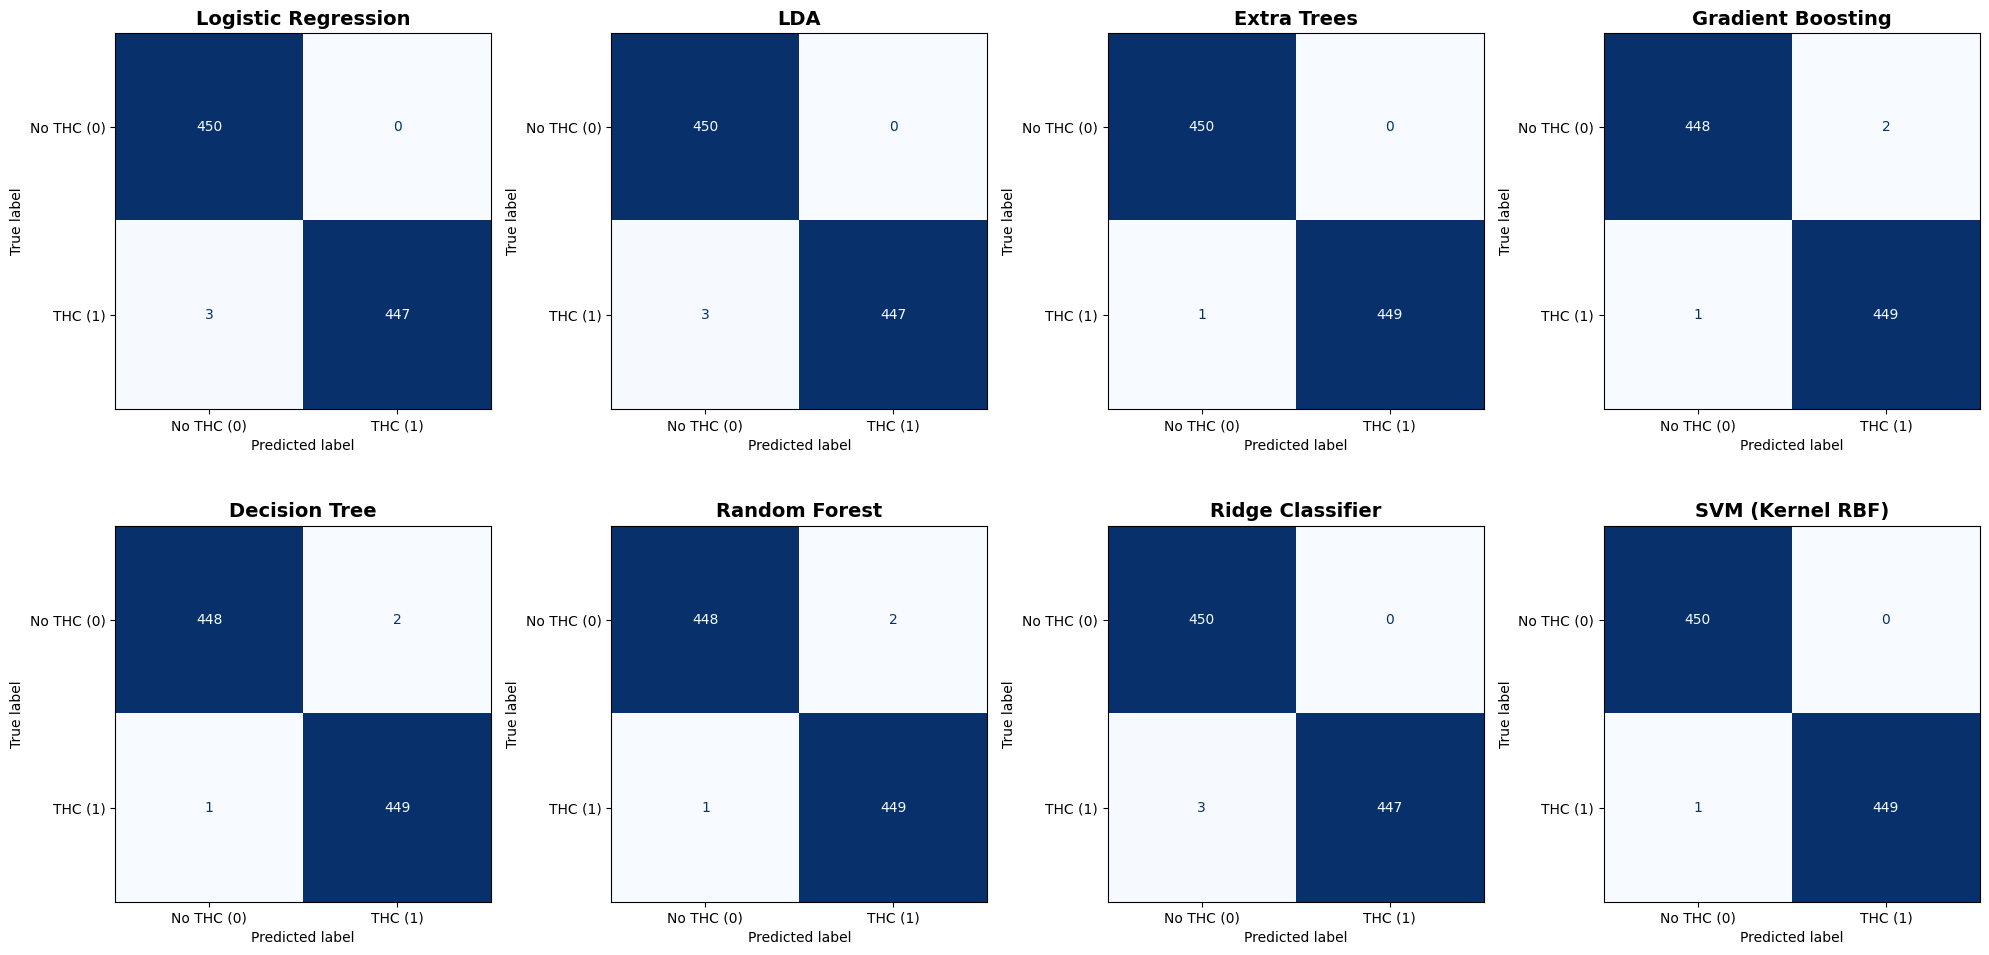


 Permutation Feature Importance (fit ทั้งชุด, n_repeats=30)
  ✓ Logistic Regression
  ✓ LDA
  ✓ Extra Trees
  ✓ Gradient Boosting
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Ridge Classifier
  ✓ SVM (Kernel RBF)


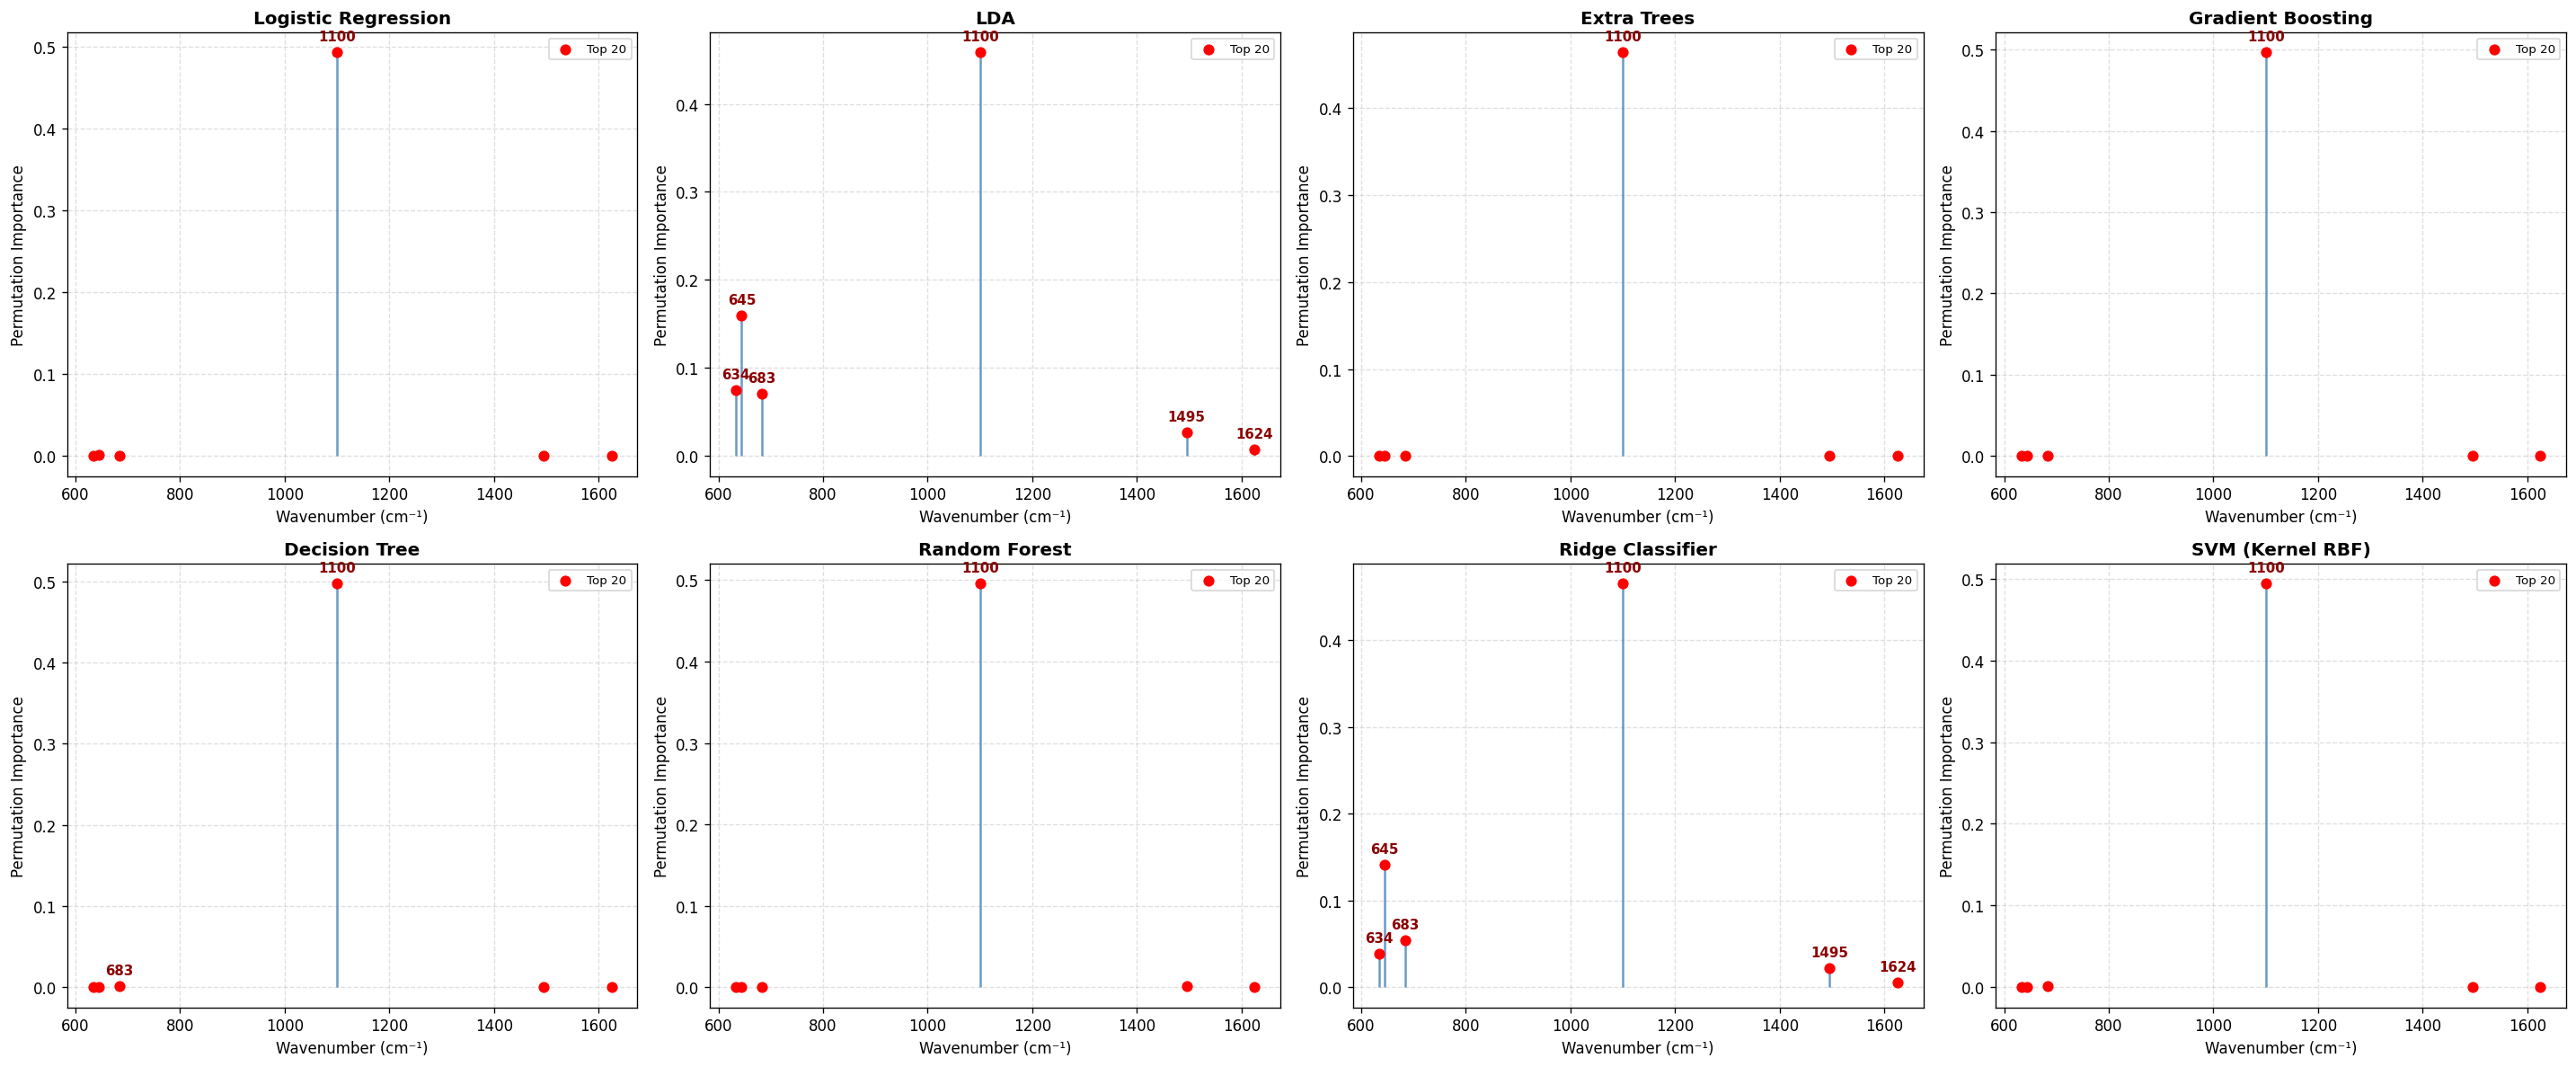

{'Logistic Regression': {'acc': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0], 'precision': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'f1': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.9795918367346939, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9795918367346939, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9795918367346939, 1.0, 1.0, 1.0, 1.0, 1.0]}, 'LDA': {'acc': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0], 'precision': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 

,Accuracy,Precision,F1-score
Model,,,
Logistic Regression,0.8973,0.8627,0.8319
LDA,0.8635,0.8627,0.8627
Extra Trees,0.9216,0.8627,0.8370
Gradient Boosting,0.9208,0.8627,0.8348
Decision Tree,0.9169,0.8627,0.8350
Random Forest,0.9271,0.8627,0.8374
Ridge Classifier,0.8627,0.8627,0.8627
SVM (Kernel RBF),0.9098,0.8627,0.8231


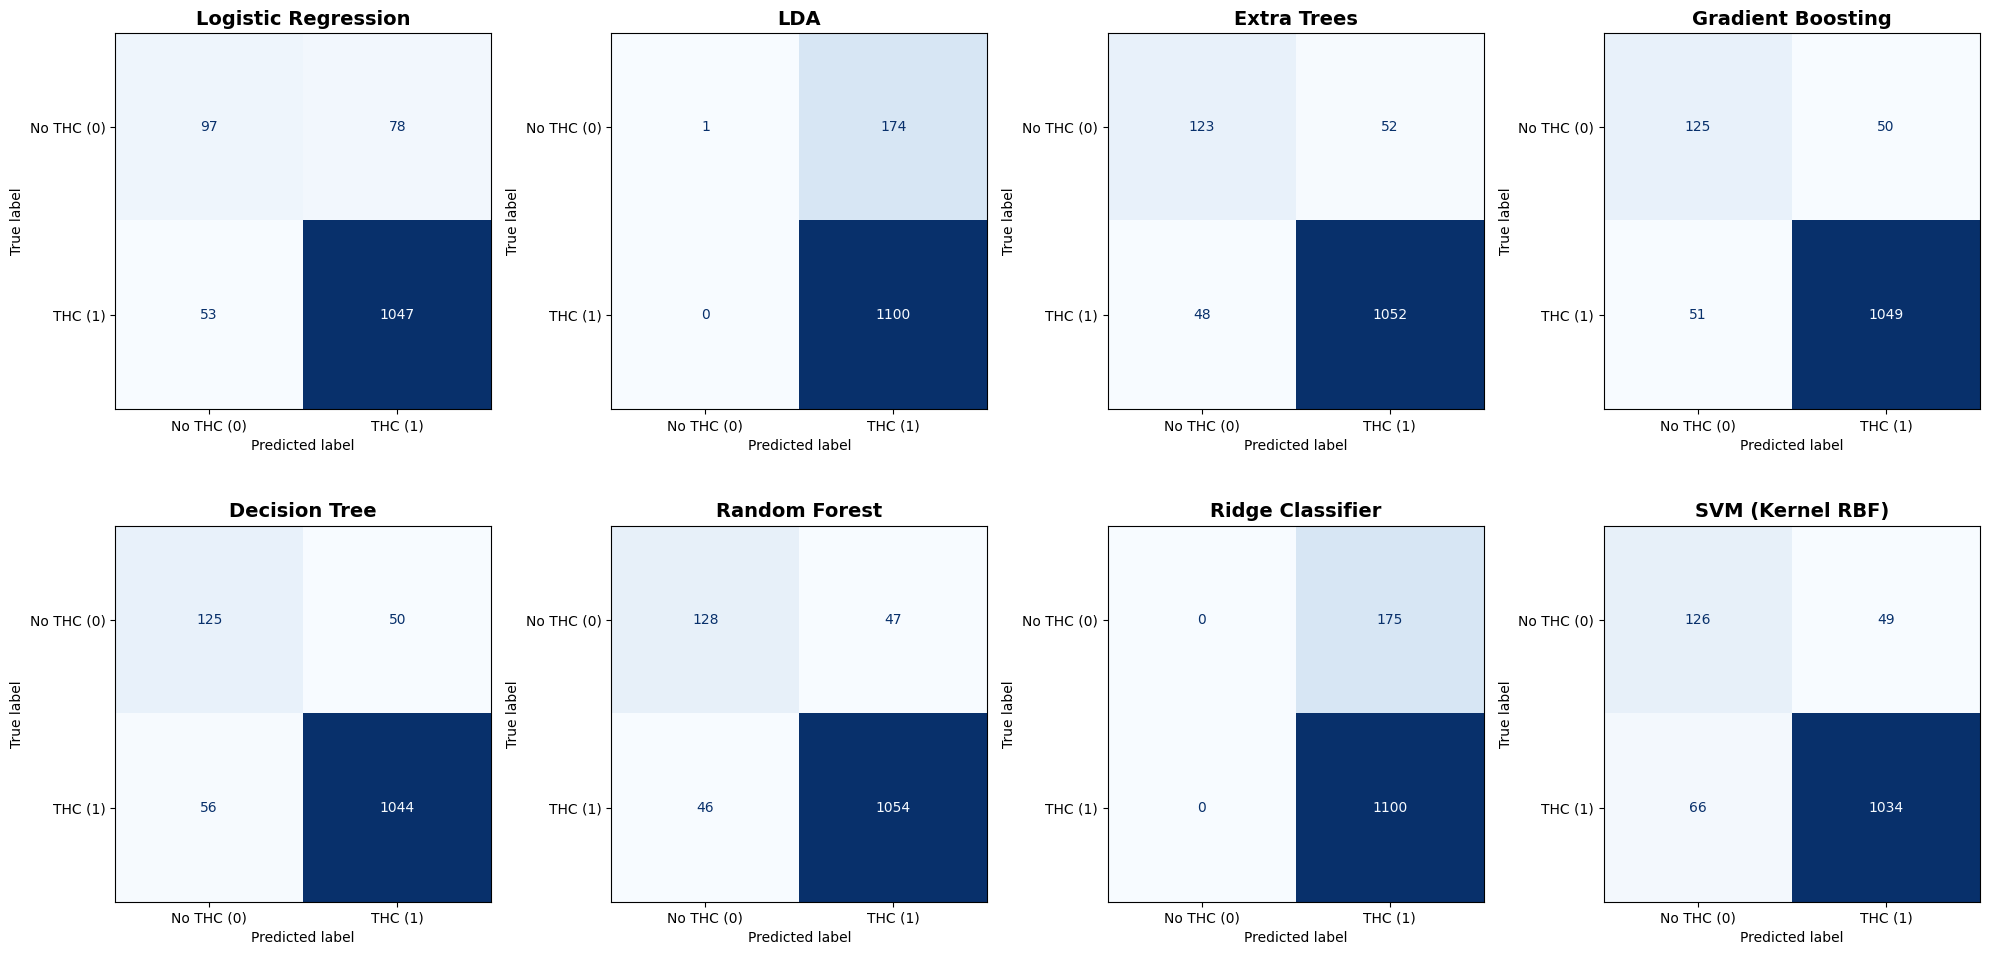


 Permutation Feature Importance (fit ทั้งชุด, n_repeats=30)
  ✓ Logistic Regression
  ✓ LDA
  ✓ Extra Trees
  ✓ Gradient Boosting
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Ridge Classifier
  ✓ SVM (Kernel RBF)


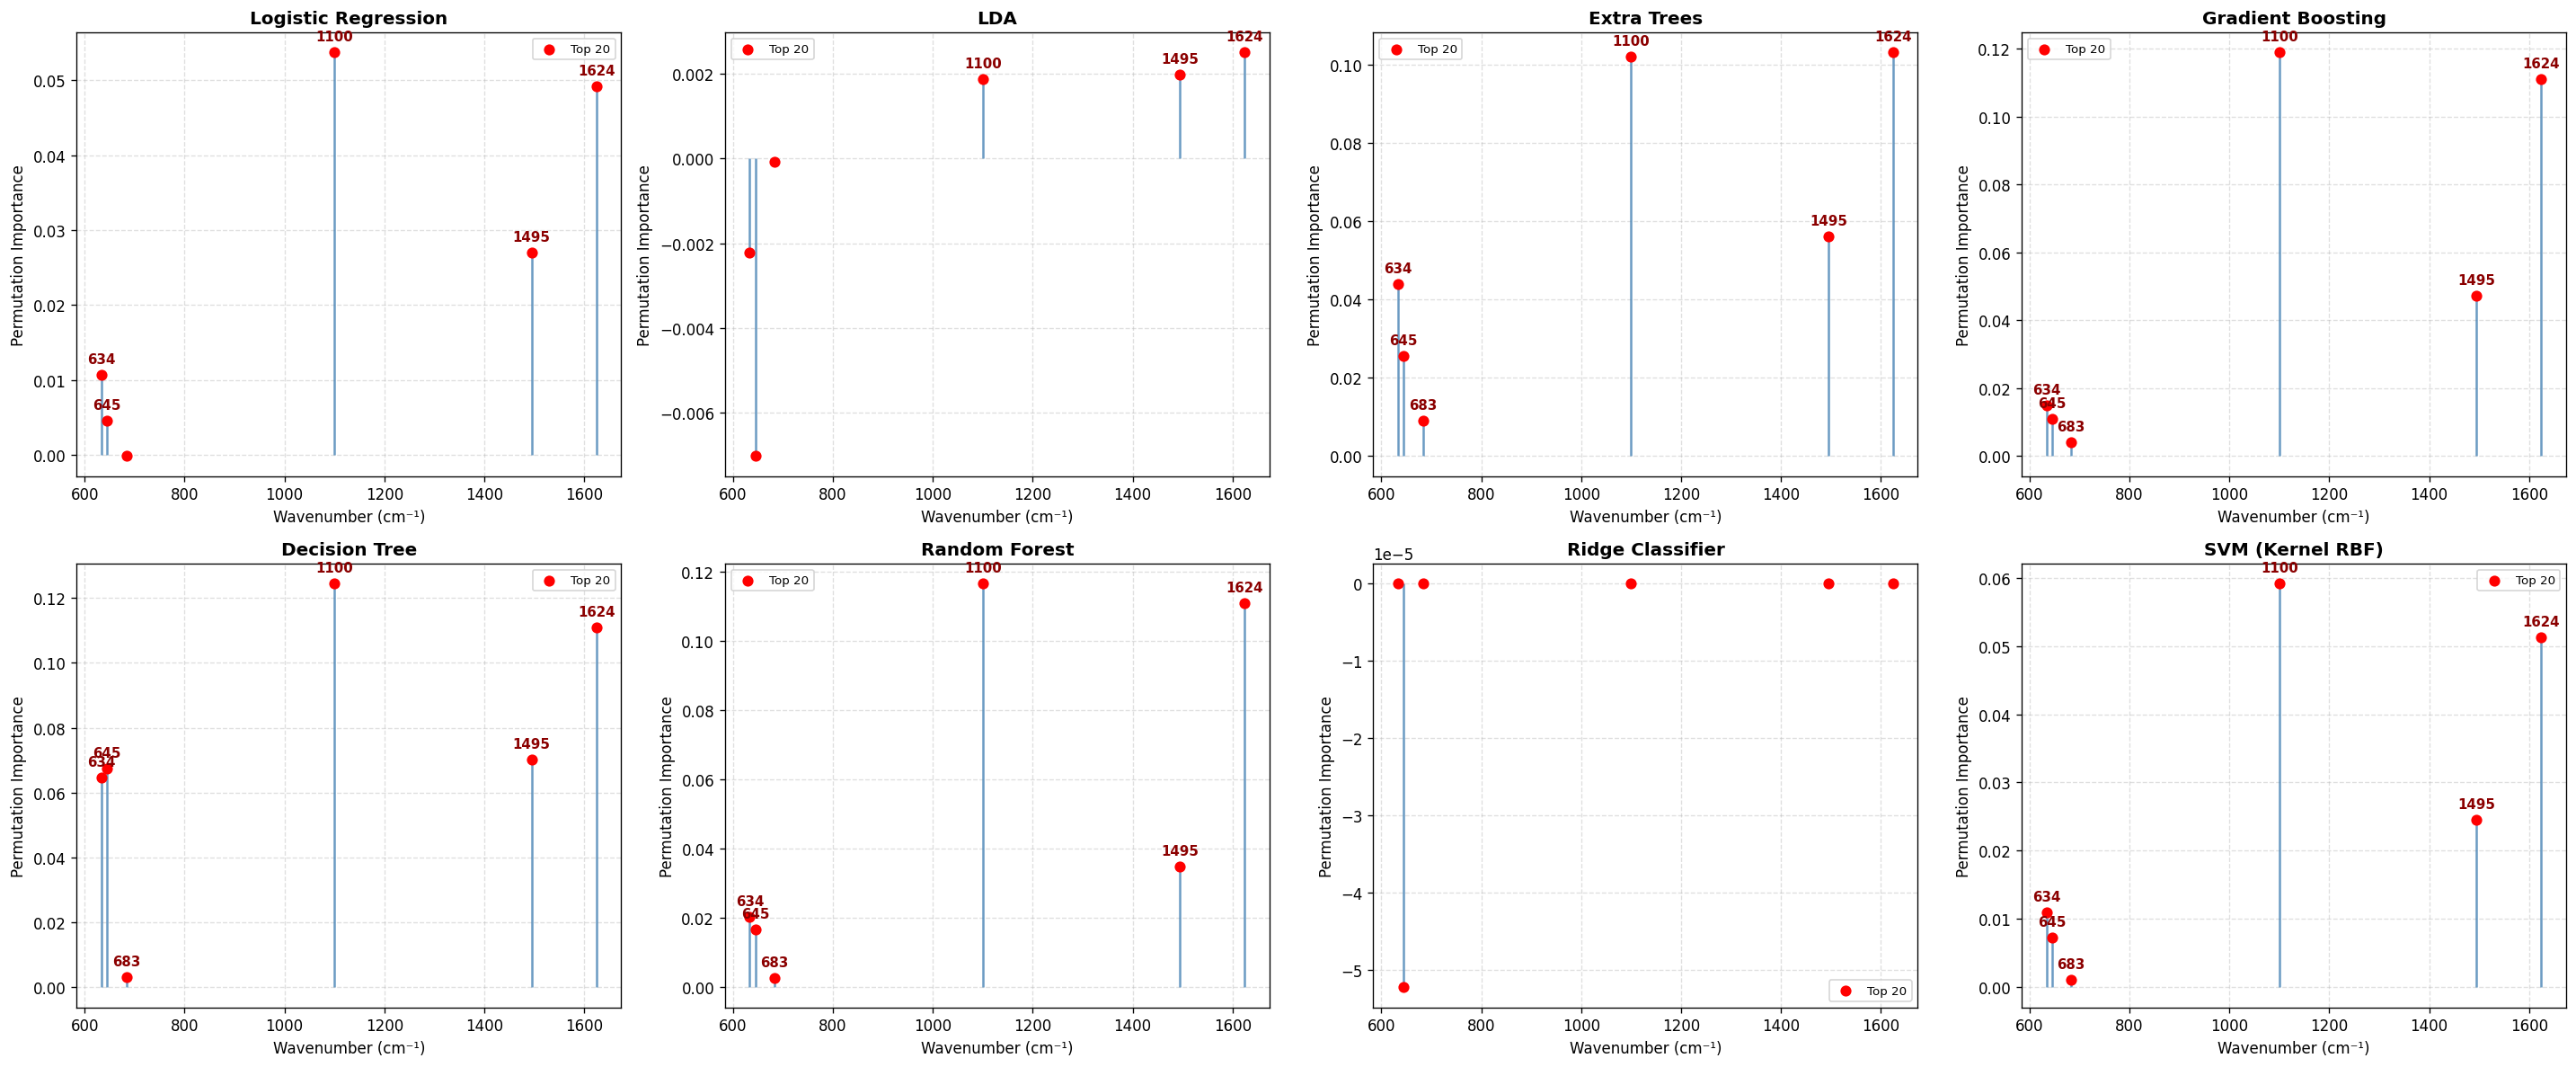

{'Logistic Regression': {'acc': [1.0, 1.0, 1.0, 0.4, 0.16, 1.0, 0.52, 0.92, 0.92, 1.0, 0.48, 0.56, 0.2, 0.0, 0.72, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.96, 1.0, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'precision': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'f1': [1.0, 1.0, 1.0, 0.5714285714285714, 0.27586206896551724, 1.0, 0.6842105263157895, 0.9583333333333334, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9795918367346939, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9795918367346939, 1.0, 0.9795918367346939, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}, 'LDA': {'acc': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.04,

In [32]:

datasets = {
    "Selectivity": df_select.drop(columns=['Substance']),
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

for name, df_current in datasets.items():
    print(f"Name:{name}")
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 1100, 1495, 1624])
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    classes, counts = np.unique(Y_final, return_counts=True)
    print(f"Class: {classes}")
    print(f"Count: {counts}")
    metrics_results, summary_df, importance = loovc(
        X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['No THC (0)', 'THC (1)']
    )
    print(metrics_results)


### 12. Threshold Experiment 6.4 ppm — Copy DataFrame

- copy `df_cal` ออกมาเป็น `df_cal_Threshold` ป้องกันการแก้ต้นฉบับ

In [16]:
df_cal_Threshold = df_cal.copy()

### 13. Re-label ตาม Threshold 6.4 ppm

- `Concentration ≤ 6.4` → `less6.4` (0)
- `Concentration >  6.4` → `more6.4` (1)

In [14]:
if not df_cal_Threshold.empty:
    df_cal_Threshold['Target'] = df_cal_Threshold['Concentration'].apply(lambda x: 'less6.4' if float(x) <= 6.4 else 'more6.4' )
    df_cal_Threshold['Target_Code'] = df_cal_Threshold['Target'].map({'less6.4': 0, 'more6.4': 1})

### 14. Sanity Check `df_cal_Threshold`

- ตรวจว่า re-label ถูกต้องหรือไม่

In [15]:
df_cal_Threshold.head()

,Wave,Intensity,Concentration,Filename,Target,Target_Code
0,1723.380859,5142.324707,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
1,1722.401367,5211.229492,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
2,1721.421875,5194.927246,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
3,1720.441406,5247.508789,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
4,1719.460938,5249.058594,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0


### 15. Run Classification @ 6.4 ppm Threshold *(commented out)*

- pipeline: `remove_duplicates → preprocessing → select_peaks (6 peaks) → loovc`
- class names: `['<= 6.4 ppm (0)', '> 6.4 ppm (1)']`

In [16]:
"""
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold.drop(columns=['Concentration']))
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 1100, 1495, 1624 ])
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
classes, counts = np.unique(Y_final, return_counts=True)
print(f"Class: {classes}")
print(f"Count: {counts}")
metrics_results, summary_df, importance = loovc(
    X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['<= 6.4 ppm (0)', '> 6.4 ppm (1)']
    )
"""

'\nwavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold.drop(columns=[\'Concentration\']))\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\nWave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 1100, 1495, 1624 ])\nprint(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\nclasses, counts = np.unique(Y_final, return_counts=True)\nprint(f"Class: {classes}")\nprint(f"Count: {counts}")\nmetrics_results, summary_df, importance = loovc(\n    X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= [\'<= 6.4 ppm (0)\', \'> 6.4 ppm (1)\']\n    )\n'

### 16. Threshold Experiment 3.2 ppm — Copy DataFrame

- copy `df_cal` แยก instance ใหม่ → `df_cal_Threshold_32`

In [17]:
df_cal_Threshold_32 = df_cal.copy()

### 17. Re-label ตาม Threshold 3.2 ppm

- `Concentration ≤ 3.2` → `less3.2` (0)
- `Concentration >  3.2` → `more3.2` (1)

In [18]:
if not df_cal_Threshold_32.empty:
    df_cal_Threshold_32['Target'] = df_cal_Threshold_32['Concentration'].apply(lambda x: 'less3.2' if float(x) <= 3.2 else 'more3.2' )
    df_cal_Threshold_32['Target_Code'] = df_cal_Threshold_32['Target'].map({'less3.2': 0, 'more3.2': 1})

### 18. Run Classification @ 3.2 ppm Threshold (Active Run)

- ใช้ 6 peaks เดิม `[634, 645, 683, 1100, 1495, 1624]`
- รัน Leave-25-out CV ครบ 8 classifiers + permutation importance
- class names: `['<= 3.2 ppm (0)', '> 3.2 ppm (1)']`

DATA:(1275, 6) Y:(1275,)
Class: [0 1]
Count: [750 525]
จำนวนครั้งในการวนลูป (n_splits): 51

กำลังรันรอบที่ 1 / 51 ... (Test Index: 43 ถึง 1181)
กำลังรันรอบที่ 10 / 51 ... (Test Index: 135 ถึง 1260)
กำลังรันรอบที่ 20 / 51 ... (Test Index: 60 ถึง 1261)
กำลังรันรอบที่ 30 / 51 ... (Test Index: 18 ถึง 1249)
กำลังรันรอบที่ 40 / 51 ... (Test Index: 17 ถึง 1257)
กำลังรันรอบที่ 50 / 51 ... (Test Index: 13 ถึง 1242)

 สรุปผลเฉลี่ยทุก metric (Average over folds)


,Accuracy,Precision,F1-score
Model,,,
Logistic Regression,0.9349,0.9216,0.9152
LDA,0.9247,0.9356,0.8981
Extra Trees,0.9561,0.9574,0.9435
Gradient Boosting,0.9506,0.9472,0.9360
Decision Tree,0.9373,0.9194,0.9162
Random Forest,0.9522,0.9542,0.9380
Ridge Classifier,0.9247,0.9356,0.8981
SVM (Kernel RBF),0.9404,0.9294,0.9222


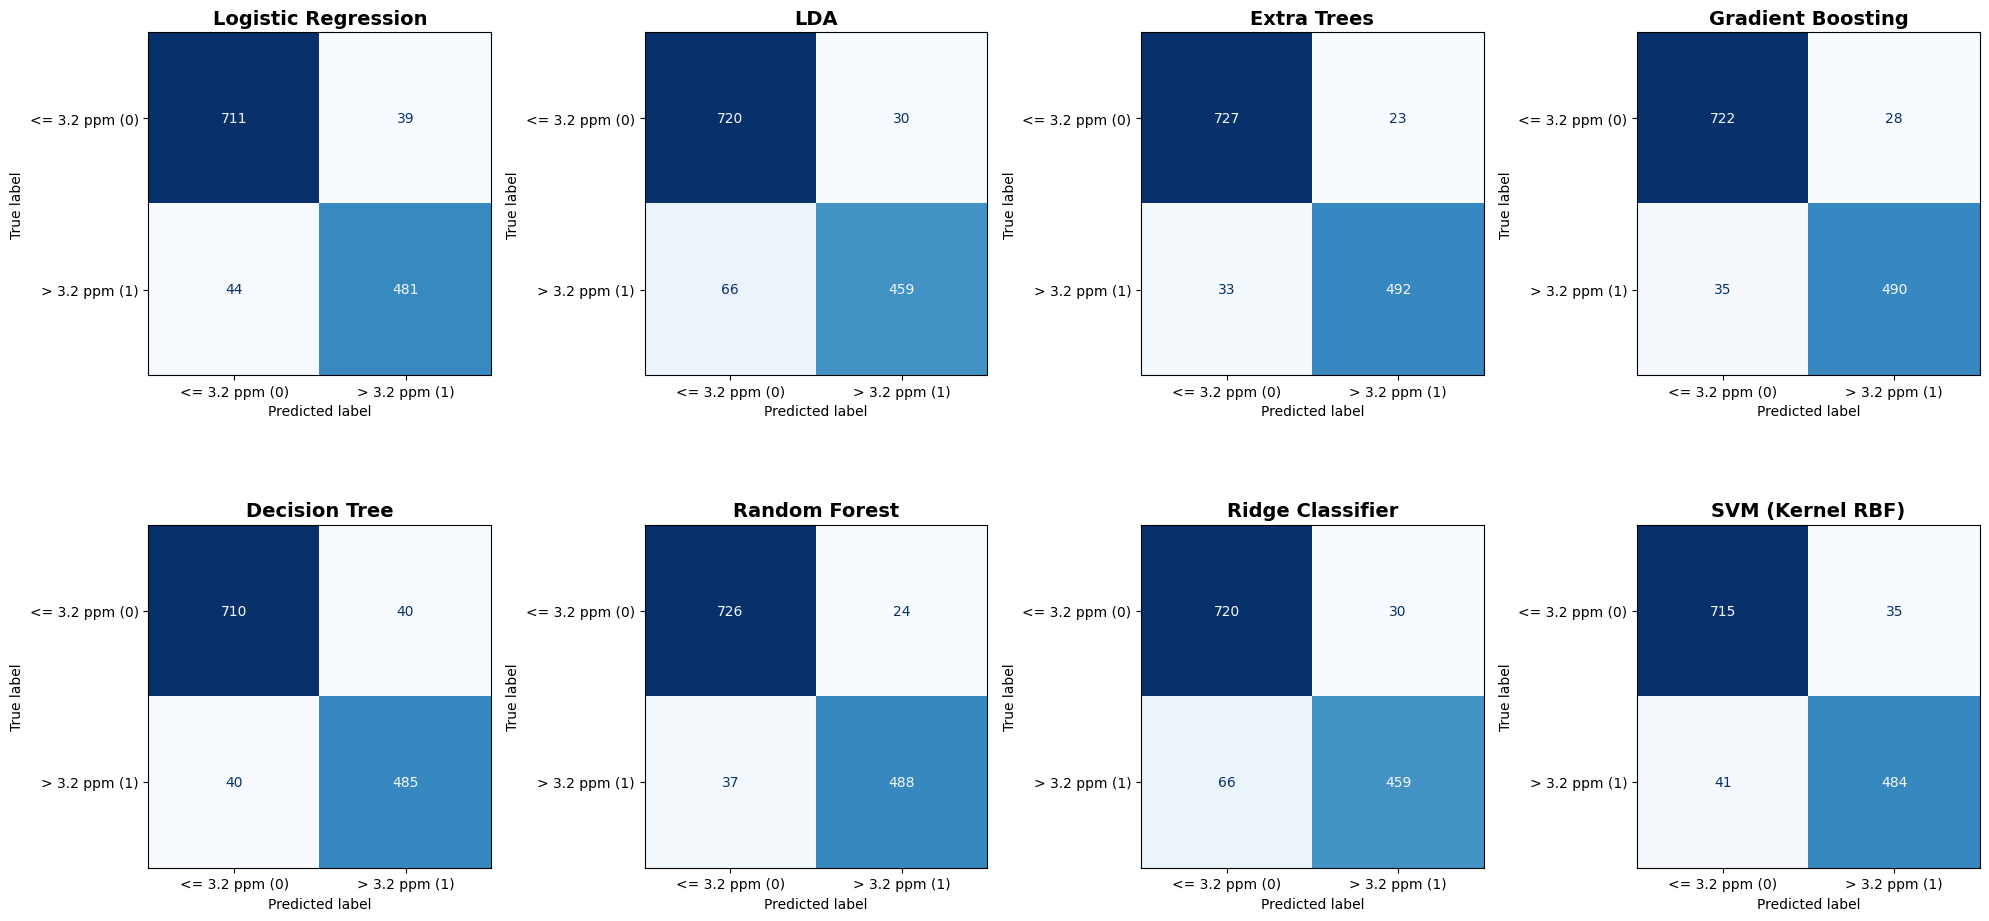


 Permutation Feature Importance (fit ทั้งชุด, n_repeats=30)
  ✓ Logistic Regression
  ✓ LDA
  ✓ Extra Trees
  ✓ Gradient Boosting
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Ridge Classifier
  ✓ SVM (Kernel RBF)


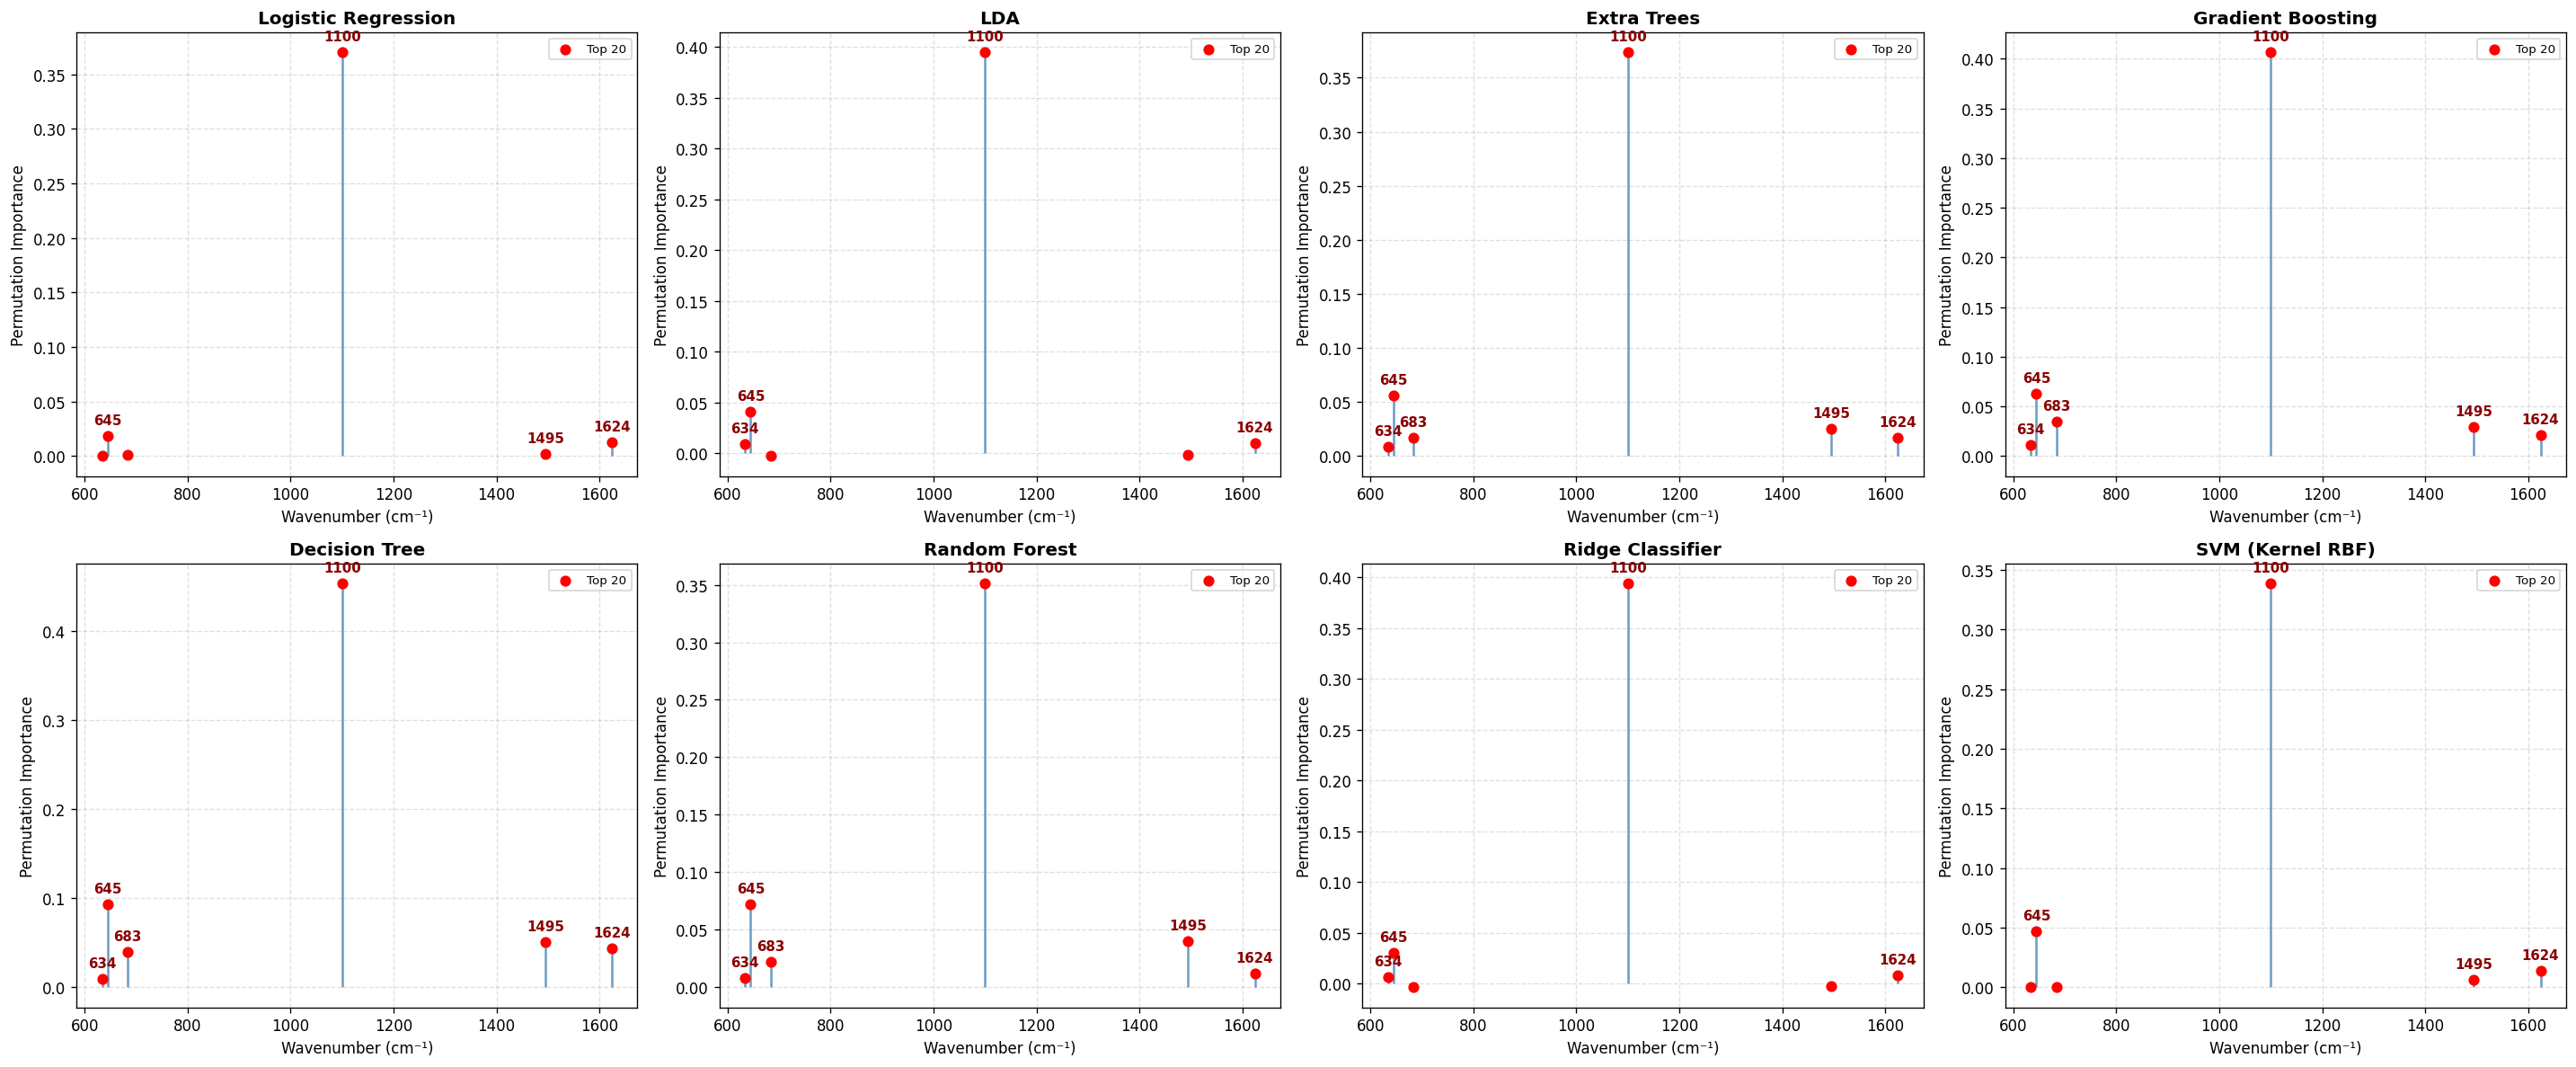

In [22]:
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold_32.drop(columns=['Concentration']))
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers , target_peaks= [634, 645, 683, 1100, 1495, 1624])
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
classes, counts = np.unique(Y_final, return_counts=True)
print(f"Class: {classes}")
print(f"Count: {counts}")
metrics_results, summary_df, importance = loovc(
    X_peaks, Y_final, wavenumbers=Wave_peaks , class_name= ['<= 3.2 ppm (0)', '> 3.2 ppm (1)']
    )